In [23]:
import pandas as pd

In [24]:
# orders_quality.csv
url = "https://drive.google.com/file/d/1K0We2jV6NPImZ_zVBbPAe-Kt7bKNXKD1/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_quality = pd.read_csv(path)

# orderlines_quality.csv
url = "https://drive.google.com/file/d/1igzQzYbq_9uQHNrBBGxAtYJH1s6JD1EJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_quality = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1crLwyUJvGMDX6kO40hVjLfvgNA4q12Qd/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

#brands_cl.csv
url = "https://drive.google.com/file/d/1An7BhXNvbodnNIdY0p9HiF1m9nBfpzaV/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_cl = pd.read_csv(path)


In [25]:
orders_quality.columns

Index(['order_id', 'created_date', 'total_paid', 'state'], dtype='object')

In [26]:
orderlines_quality.columns

Index(['id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price',
       'date'],
      dtype='object')

In [27]:
products_cl.columns

Index(['sku', 'name', 'desc', 'price', 'in_stock', 'type'], dtype='object')

In [28]:
brands_cl.columns

Index(['short', 'long'], dtype='object')

# 1.Data Integration

In [29]:
# Merging Orderlines with products to calculate the price difference(discount)

df_mid = orderlines_quality.merge(products_cl, on='sku', how='left')
df_mid


,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404
...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230


In [30]:
# 2. Find the Ghost SKUs (Left join creates NaN for missing product info)
ghost_skus = df_mid[df_mid['price'].isna()]

# 3. Report the finding
print(f"Total rows with missing product info: {len(ghost_skus)}")
print(f"Unique Ghost SKUs: {ghost_skus['sku'].nunique()}")

Total rows with missing product info: 0
Unique Ghost SKUs: 0


In [31]:
# Extract the brand code from SKU
df_mid['brand_code'] = df_mid['sku'].str[:3]

# Merge with brands
df_mid = df_mid.merge(brands_cl, left_on='brand_code', right_on='short', how='left')

# Final merge using the order ID
df_final = df_mid.merge(orders_quality, left_on='id_order', right_on='order_id', how='left')

# CRITICAL: Filter for valid orders only (usually 'Completed' or 'Shipped')
# Check your 'state' column values first: df_final['state'].unique()
df_final = df_final.loc[df_final['state'] == 'Completed']
df_final

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,in_stock,type,brand_code,short,long,order_id,created_date,total_paid,state
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1,12755395,OWC,OWC,OWC,299545,2017-01-01 01:51:47,51.48,Completed
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0,5720,IOT,IOT,iOttie,299546,2017-01-01 01:57:34,18.99,Completed
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1,13005399,APP,APP,Apple,295347,2017-01-01 02:02:38,72.19,Completed
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0,1298,CRU,CRU,Crucial,299556,2017-01-01 02:30:08,65.89,Completed
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0,11905404,PEB,PEB,Pebble,299561,2017-01-01 02:39:47,154.48,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,APP,Apple,527035,2018-03-14 11:44:34,37.98,Completed
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,APP,Apple,527070,2018-03-14 11:50:48,24.97,Completed
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,APP,Apple,527074,2018-03-14 11:51:42,24.97,Completed
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1,1230,APP,APP,Apple,527096,2018-03-14 11:58:40,34.96,Completed


In [32]:
df_final.columns

Index(['id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price',
       'date', 'name', 'desc', 'price', 'in_stock', 'type', 'brand_code',
       'short', 'long', 'order_id', 'created_date', 'total_paid', 'state'],
      dtype='object')

## Find the Discount

In [33]:
#Calculate the discount: Original Price - Sold Price
df_final['discount'] = df_final['price'] - df_final['unit_price']


In [34]:
df_final['discount'].describe()

,discount
count,53231.000000
mean,26.116673
std,45.545881
min,-170.990000
25%,5.250000
50%,15.000000
75%,31.000000
max,1320.000000


There is some negative values, so we have to find how many rows with negative values.

In [35]:
negative_count = (df_final['discount'] < 0).sum()
print(f"Total rows with negative discounts: {negative_count}")


Total rows with negative discounts: 1571


In [36]:
# Calculate Discount percentage

df_final['disc_perc'] = ((df_final['discount']/df_final['price'])*100).round(2)

In [37]:
df_final["disc_perc"].describe()

,disc_perc
count,53231.000000
mean,21.377940
std,18.145655
min,-212.270000
25%,9.090000
50%,17.650000
75%,28.590000
max,97.140000


### The "Clip" Method (Recommended)
Those 1,571 rows represent about 0.5% to 2% of atypical Eniac dataset.While it's a small portion,it's enough to skew your "No Discount" category if not handled.  
Since my goal is to analyze discounts, a price increase is technically a 0% discount. So i can "clip" the values so that anything below zero becomes zero.

•	The Board's Perspective: These 1,547 sales were "Premium" sales (sold above MSRP). By moving them into the "No Discount (0%)" tier, you are showing the Board that there is a segment of customers willing to pay even more than the list price for quality/availability.

In [38]:
# Set the negative values as 0
df_final.loc[df_final['disc_perc'] < 0, "disc_perc"] = 0

In [39]:
df_final["disc_perc"].describe()

,disc_perc
count,53231.000000
mean,21.568381
std,17.744307
min,0.000000
25%,9.090000
50%,17.650000
75%,28.590000
max,97.140000


## Find the Total Revenue

In [40]:
# 2. Total Revenue per line (Quantity * Paid Price)
df_final['total_revenue'] = df_final['product_quantity'] * df_final['unit_price']
df_final

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,...,brand_code,short,long,order_id,created_date,total_paid,state,discount,disc_perc,total_revenue
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,...,OWC,OWC,OWC,299545,2017-01-01 01:51:47,51.48,Completed,13.50,22.13,47.49
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,...,IOT,IOT,iOttie,299546,2017-01-01 01:57:34,18.99,Completed,3.96,17.25,18.99
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,...,APP,APP,Apple,295347,2017-01-01 02:02:38,72.19,Completed,16.81,18.89,72.19
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,...,CRU,CRU,Crucial,299556,2017-01-01 02:30:08,65.89,Completed,16.09,20.90,60.90
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,...,PEB,PEB,Pebble,299561,2017-01-01 02:39:47,154.48,Completed,157.50,52.50,142.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,APP,APP,Apple,527035,2018-03-14 11:44:34,37.98,Completed,15.01,60.04,9.99
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,APP,APP,Apple,527070,2018-03-14 11:50:48,24.97,Completed,15.01,60.04,19.98
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,APP,APP,Apple,527074,2018-03-14 11:51:42,24.97,Completed,15.01,60.04,19.98
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,APP,APP,Apple,527096,2018-03-14 11:58:40,34.96,Completed,15.01,60.04,29.97


In [41]:
df_final.dtypes

,0
id,int64
id_order,int64
product_id,int64
product_quantity,int64
sku,object
unit_price,float64
date,object
name,object
desc,object
price,float64


## 2.Seasonality Analysis

In [42]:
# 3. Date conversion for Seasonality
df_final['created_date'] = pd.to_datetime(df_final['created_date'])

In [43]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53231 entries, 0 to 53230
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                53231 non-null  int64         
 1   id_order          53231 non-null  int64         
 2   product_id        53231 non-null  int64         
 3   product_quantity  53231 non-null  int64         
 4   sku               53231 non-null  object        
 5   unit_price        53231 non-null  float64       
 6   date              53231 non-null  object        
 7   name              53231 non-null  object        
 8   desc              53231 non-null  object        
 9   price             53231 non-null  float64       
 10  in_stock          53231 non-null  int64         
 11  type              53220 non-null  object        
 12  brand_code        53231 non-null  object        
 13  short             53195 non-null  object        
 14  long              53195 non

In [44]:
df_final['year'] = df_final['created_date'].dt.year
df_final['month'] = df_final['created_date'].dt.month

In [45]:
#  Create a 'Year-Month' column for clean charting
df_final['year_month'] = df_final['created_date'].dt.to_period('M')

Analyze the "Black Friday Effect" (Seasonality)

In [46]:
# Group by month to see the trend
seasonality = df_final.groupby('month').agg({
    'total_revenue': 'sum',
    'disc_perc': 'mean',
    'id_order': 'nunique'
}).rename(columns={'id_order': 'order_count'})

print(seasonality)

       total_revenue  disc_perc  order_count
month                                       
1         1465341.44  23.638584         9108
2          856455.26  21.160039         4976
3          245521.98  21.701878         1517
4          228090.63  18.711477         1460
5          331214.98  15.851169         1651
6          286575.67  17.615193         1329
7          599404.93  25.283145         3074
8          379560.32  20.767058         2098
9          387942.85  20.158179         1880
10         547599.55  22.123315         2768
11        1503718.88  21.961666         6261
12         985777.91  19.460142         4863


/tmp/ipykernel_18799/2590616477.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='month', y='total_revenue', palette="Blues_d", ax=ax1)


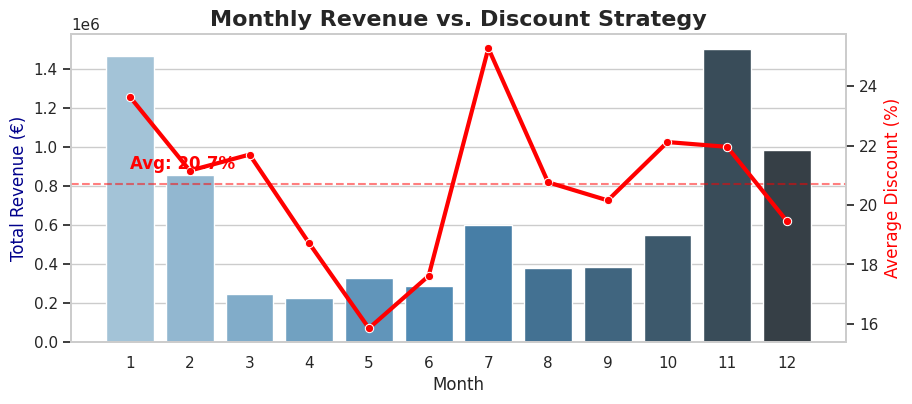

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
plot_data = seasonality.reset_index()

# 2. Set the visual style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 4))

# 3. Plot Revenue as a Bar Chart (Left Axis)
sns.barplot(data=plot_data, x='month', y='total_revenue', palette="Blues_d", ax=ax1)
ax1.set_title('Monthly Revenue vs. Discount Strategy', fontsize=16, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue (€)', fontsize=12, color='darkblue')

# 4. Create the second axis for Discount Percentage (Right Axis)
ax2 = ax1.twinx()
sns.lineplot(data=plot_data, x=plot_data.index, y='disc_perc', color='red', marker='o', linewidth=3, ax=ax2)
ax2.set_ylabel('Average Discount (%)', fontsize=12, color='red')
ax2.grid(False) # Turn off grid for the second axis to keep it clean

# 5. Add a horizontal line for the "Annual Average Discount" to give context
avg_disc = plot_data['disc_perc'].mean()
ax2.axhline(avg_disc, color='red', linestyle='--', alpha=0.5)
ax2.text(0, avg_disc+0.5, f'Avg: {avg_disc:.1f}%', color='red', fontweight='bold')

plt.show()

# 3. Discount Tier Analysis(The Sweet Spot)

In [48]:
# Create Discount "Buckets"
df_final['discount_tier']="Unknown"

df_final.loc[df_final['disc_perc'] == 0, 'discount_tier'] = 'No discount (0%)'
df_final.loc[(df_final['disc_perc'] > 0) & (df_final['disc_perc'] <= 10), 'discount_tier'] = 'Low (1-10%)'
df_final.loc[(df_final['disc_perc'] > 10) & (df_final['disc_perc'] <= 30), 'discount_tier'] = 'Medium (11-30%)'
df_final.loc[df_final['disc_perc'] > 30, 'discount_tier'] = 'High(above 30%)'

df_final

,id,id_order,product_id,product_quantity,sku,unit_price,date,name,desc,price,...,created_date,total_paid,state,discount,disc_perc,total_revenue,year,month,year_month,discount_tier
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,...,2017-01-01 01:51:47,51.48,Completed,13.50,22.13,47.49,2017,1,2017-01,Medium (11-30%)
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,...,2017-01-01 01:57:34,18.99,Completed,3.96,17.25,18.99,2017,1,2017-01,Medium (11-30%)
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,...,2017-01-01 02:02:38,72.19,Completed,16.81,18.89,72.19,2017,1,2017-01,Medium (11-30%)
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,...,2017-01-01 02:30:08,65.89,Completed,16.09,20.90,60.90,2017,1,2017-01,Medium (11-30%)
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,...,2017-01-01 02:39:47,154.48,Completed,157.50,52.50,142.49,2017,1,2017-01,High(above 30%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,2018-03-14 11:44:34,37.98,Completed,15.01,60.04,9.99,2018,3,2018-03,High(above 30%)
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,2018-03-14 11:50:48,24.97,Completed,15.01,60.04,19.98,2018,3,2018-03,High(above 30%)
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,2018-03-14 11:51:42,24.97,Completed,15.01,60.04,19.98,2018,3,2018-03,High(above 30%)
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,...,2018-03-14 11:58:40,34.96,Completed,15.01,60.04,29.97,2018,3,2018-03,High(above 30%)


In [49]:
bucket_analysis = df_final.groupby('discount_tier').agg({
    'total_revenue': 'sum',
    'product_quantity': 'sum'
})
print(bucket_analysis)

                  total_revenue  product_quantity
discount_tier                                    
High(above 30%)       602287.37             13824
Low (1-10%)          2681656.53             12254
Medium (11-30%)      3955803.57             29587
No discount (0%)      577456.93              4346


In [50]:
# 2. Revenue Share: The percentage contribution of each bucket
total_revenue = bucket_analysis['total_revenue'].sum()
bucket_analysis['rev_share_perc'] = (bucket_analysis['total_revenue'] / total_revenue) * 100

In [51]:
 #3. ARPU: Revenue per single unit sold
bucket_analysis['arpu'] = bucket_analysis['total_revenue'] / bucket_analysis['product_quantity']

In [52]:
 #Let's see the results
print(bucket_analysis[['total_revenue', 'product_quantity', 'rev_share_perc', 'arpu']])

                  total_revenue  product_quantity  rev_share_perc        arpu
discount_tier                                                                
High(above 30%)       602287.37             13824        7.704639   43.568241
Low (1-10%)          2681656.53             12254       34.304547  218.839279
Medium (11-30%)      3955803.57             29587       50.603814  133.700732
No discount (0%)      577456.93              4346        7.387001  132.870900


/tmp/ipykernel_18799/2381086981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bucket_analysis.reset_index(), x='discount_tier', y='arpu', palette='viridis')


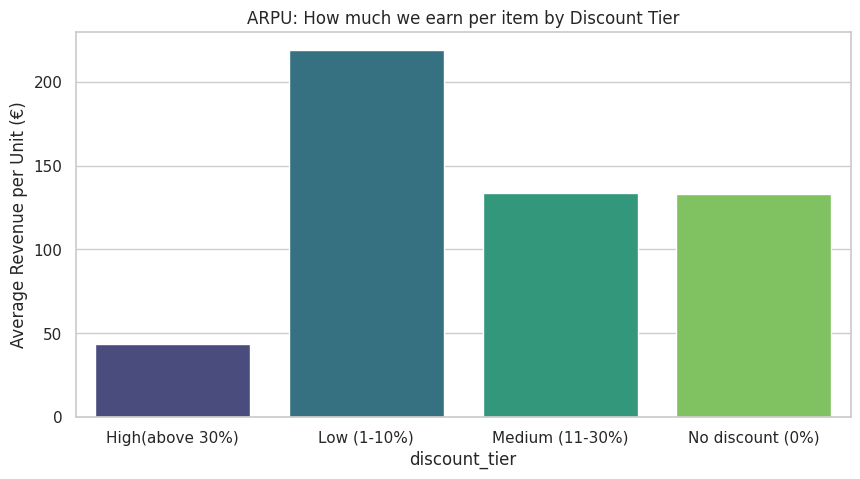

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Quick bar chart for ARPU
plt.figure(figsize=(10, 5))
sns.barplot(data=bucket_analysis.reset_index(), x='discount_tier', y='arpu', palette='viridis')
plt.title('ARPU: How much we earn per item by Discount Tier')
plt.ylabel('Average Revenue per Unit (€)')
plt.show()

/tmp/ipykernel_18799/644221972.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bucket_analysis.reset_index(), x='discount_tier', y='rev_share_perc', palette="Blues_d", ax=ax1, alpha=0.8)


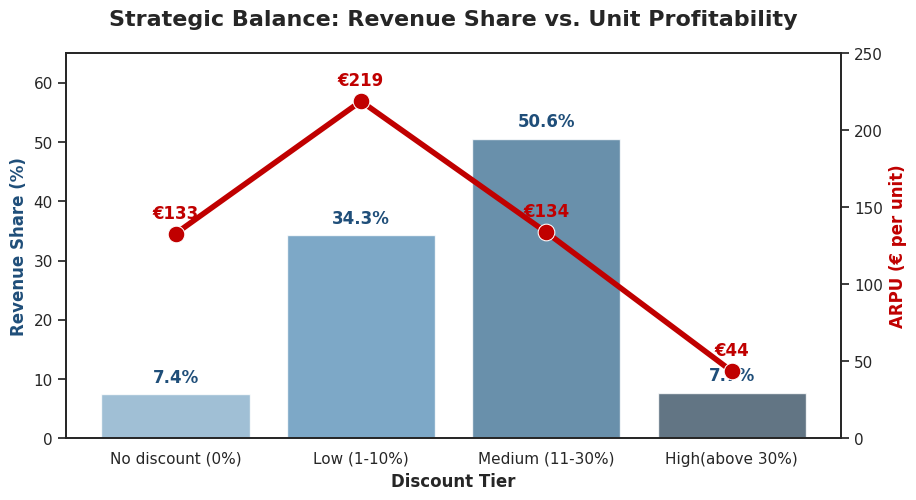

In [54]:
# Ensure your data is sorted by the logic of the tiers
tier_order = ['No discount (0%)', 'Low (1-10%)', 'Medium (11-30%)', 'High(above 30%)']
bucket_analysis = bucket_analysis.reindex(tier_order)

sns.set_theme(style="white")
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1. Plot Revenue Share as Bars (Left Axis)
sns.barplot(data=bucket_analysis.reset_index(), x='discount_tier', y='rev_share_perc', palette="Blues_d", ax=ax1, alpha=0.8)
ax1.set_ylabel('Revenue Share (%)', fontsize=12, fontweight='bold', color='#1f4e79')
ax1.set_xlabel('Discount Tier', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 65) # Adjust based on your max share

# 2. Plot ARPU as a Line (Right Axis)
ax2 = ax1.twinx()
sns.lineplot(data=bucket_analysis.reset_index(), x=range(len(tier_order)), y='arpu', marker='o', markersize=12, color='#c00000', linewidth=4, ax=ax2)
ax2.set_ylabel('ARPU (€ per unit)', fontsize=12, fontweight='bold', color='#c00000')
ax2.set_ylim(0, 250)

# 3. Add Labels to make it board-ready
for i, (idx, row) in enumerate(bucket_analysis.iterrows()):
    ax1.text(i, row['rev_share_perc'] + 2, f"{row['rev_share_perc']:.1f}%", color='#1f4e79', ha="center", fontweight='bold')
    ax2.text(i, row['arpu'] + 10, f"€{row['arpu']:.0f}", color='#c00000', ha="center", fontweight='bold')

plt.title('Strategic Balance: Revenue Share vs. Unit Profitability', fontsize=16, fontweight='bold', pad=20)
plt.grid(False)
plt.show()

# 4. Strategic Categorization


In [55]:
# Category Creation

def get_clean_category(row):
    # Combine name and description for better searching
    text = (str(row['name']) + " " + str(row['desc'])).lower()

    # Priority order: High-value items first
    if "macbook" in text: return "laptop"
    elif "imac" in text or "mac mini" in text or "mac pro" in text: return "desktop"
    elif "iphone" in text: return "smartphone"
    elif "ipad" in text or "tablet" in text: return "tablet"
    elif "watch" in text: return "smartwatch"
    elif "server" in text or "nas" in text or "synology" in text: return "server"
    elif "ssd" in text or "hard drive" in text or "storage" in text: return "storage"
    elif "ram" in text or "memory" in text: return "ram"
    elif "monitor" in text: return "monitor"
    elif "refurbished" in text or "reconditioned" in text: return "refurbished"

    # Accessories and others
    elif "keyboard" in text: return "keyboard"
    elif "mouse" in text or "trackpad" in text: return "mouse"
    elif "headset" in text or "headphones" in text: return "headset"
    elif "speaker" in text: return "speaker"
    elif "camera" in text: return "camera"
    elif "case" in text or "funda" in text or "shell" in text: return "case"
    elif "backpack" in text: return "backpack"
    elif "cable" in text or "connector" in text: return "cable"
    elif "adapter" in text: return "adapter"
    elif "charger" in text: return "charger"
    elif "battery" in text: return "battery"
    elif "dock" in text or "hub" in text: return "dock"
    elif "stand" in text or "support" in text: return "stand"

    return "other"

# Apply this to your df_final
df_final['category_clean'] = df_final.apply(get_clean_category, axis=1)

In [56]:
# 1. Apply your function first to get all categories
df_final['category_clean'] = df_final.apply(get_clean_category, axis=1)

# 2. Identify the Top 10 categories by frequency
top_10 = df_final['category_clean'].value_counts().nlargest(10).index

# 3. If a category is NOT in the Top 10, rename it to "other"
df_final['category_clean'] = df_final['category_clean'].apply(lambda x: x if x in top_10 else 'other')

# 4. Check your result
print(df_final['category_clean'].value_counts())

category_clean
smartphone    19401
laptop         8194
other          7669
storage        5397
tablet         3704
desktop        2738
server         2218
smartwatch     1507
monitor        1367
adapter        1036
Name: count, dtype: int64


/tmp/ipykernel_18799/3086731110.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='price', y='category_clean', order=order_list, palette='viridis')


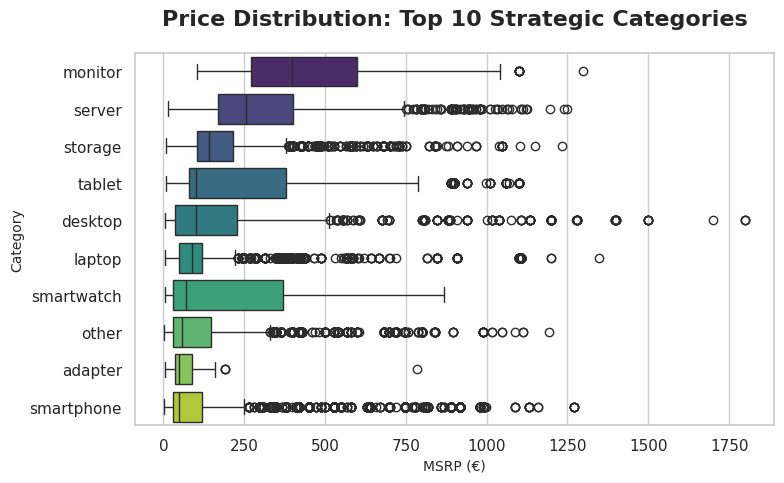

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Sort the categories by their median price so the most expensive are at the top
order_list = df_final.groupby('category_clean')['price'].median().sort_values(ascending=False).index

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 3. Create the Horizontal Boxplot
sns.boxplot(data=df_final, x='price', y='category_clean', order=order_list, palette='viridis')

# 4. Add clear labels for the Board
plt.title('Price Distribution: Top 10 Strategic Categories', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('MSRP (€)', fontsize=10)
plt.ylabel('Category', fontsize=10)

plt.tight_layout()
plt.show()

In [58]:
df_final.columns

Index(['id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price',
       'date', 'name', 'desc', 'price', 'in_stock', 'type', 'brand_code',
       'short', 'long', 'order_id', 'created_date', 'total_paid', 'state',
       'discount', 'disc_perc', 'total_revenue', 'year', 'month', 'year_month',
       'discount_tier', 'category_clean'],
      dtype='object')

We exclude non-essential columns from the fianl DataFrame to improve clarity and focus on key insights.

In [59]:
#Create the copy
df_report = df_final.copy()

# Define the columns you want to keep
cols_to_keep = [
    'sku', 'name', 'long', 'category_clean',
    'price', 'unit_price', 'product_quantity', 'total_revenue',
    'disc_perc', 'discount_tier',
    'created_date', 'year_month', 'state'
]

# Filter the dataframe
df_report = df_report[cols_to_keep]

# Rename 'long' to 'brand_name' for clarity
df_report = df_report.rename(columns={'long': 'brand_name'})


In [67]:
df_report.columns

Index(['sku', 'name', 'brand_name', 'category_clean', 'price', 'unit_price',
       'product_quantity', 'total_revenue', 'disc_perc', 'discount_tier',
       'created_date', 'year_month', 'state'],
      dtype='object')